In [1]:
import os
os.chdir(r"E:\Future Interns\Task 3 - Resume  Candidate Screening System\Code")
os.getcwd()

'E:\\Future Interns\\Task 3 - Resume  Candidate Screening System\\Code'

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk

In [3]:
jd_df=pd.read_csv("job_descriptions.csv")
jd_df.head()

,Job Id,Experience,Qualifications,Salary Range,location,Country,latitude,longitude,Work Type,Company Size,...,Contact,Job Title,Role,Job Portal,Job Description,Benefits,skills,Responsibilities,Company,Company Profile
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,54.2361,-4.5481,Intern,26801,...,001-381-930-7517x737,Digital Marketing Specialist,Social Media Manager,Snagajob,Social Media Managers oversee an organizations...,"{'Flexible Spending Accounts (FSAs), Relocatio...","Social media platforms (e.g., Facebook, Twitte...","Manage and grow social media accounts, create ...",Icahn Enterprises,"{""Sector"":""Diversified"",""Industry"":""Diversifie..."
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,...,461-509-4216,Web Developer,Frontend Web Developer,Idealist,Frontend Web Developers design and implement u...,"{'Health Insurance, Retirement Plans, Paid Tim...","HTML, CSS, JavaScript Frontend frameworks (e.g...","Design and code user interfaces for websites, ...",PNC Financial Services Group,"{""Sector"":""Financial Services"",""Industry"":""Com..."
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao SAR, China",22.1987,113.5439,Temporary,84525,...,9687619505,Operations Manager,Quality Control Manager,Jobs2Careers,Quality Control Managers establish and enforce...,"{'Legal Assistance, Bonuses and Incentive Prog...",Quality control processes and methodologies St...,Establish and enforce quality control standard...,United Services Automobile Assn.,"{""Sector"":""Insurance"",""Industry"":""Insurance: P..."
3,688192671473044,4 to 11 Years,PhD,$65K-$91K,Porto-Novo,Benin,9.3077,2.3158,Full-Time,129896,...,+1-820-643-5431x47576,Network Engineer,Wireless Network Engineer,FlexJobs,"Wireless Network Engineers design, implement, ...","{'Transportation Benefits, Professional Develo...",Wireless network design and architecture Wi-Fi...,"Design, configure, and optimize wireless netwo...",Hess,"{""Sector"":""Energy"",""Industry"":""Mining, Crude-O..."
4,117057806156508,1 to 12 Years,MBA,$64K-$87K,Santiago,Chile,-35.6751,-71.5429,Intern,53944,...,343.975.4702x9340,Event Manager,Conference Manager,Jobs2Careers,A Conference Manager coordinates and manages c...,"{'Flexible Spending Accounts (FSAs), Relocatio...",Event planning Conference logistics Budget man...,Specialize in conference and convention planni...,Cairn Energy,"{""Sector"":""Energy"",""Industry"":""Energy - Oil & ..."


In [4]:
jd_df.columns

Index(['Job Id', 'Experience', 'Qualifications', 'Salary Range', 'location',
       'Country', 'latitude', 'longitude', 'Work Type', 'Company Size',
       'Job Posting Date', 'Preference', 'Contact Person', 'Contact',
       'Job Title', 'Role', 'Job Portal', 'Job Description', 'Benefits',
       'skills', 'Responsibilities', 'Company', 'Company Profile'],
      dtype='object')

In [5]:
resume_df=pd.read_csv("Resume.csv")
resume_df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [34]:
jd_df = jd_df[
    [
        "Job Title",
        "Role",
        "Job Description",
        "skills",
        "Work Type",
        "Responsibilities",
        "Qualifications",
        "Experience"
    ]
]
print(jd_df.shape)
jd_df.head()

(1615940, 8)


,Job Title,Role,Job Description,skills,Work Type,Responsibilities,Qualifications,Experience
0,Digital Marketing Specialist,Social Media Manager,Social Media Managers oversee an organizations...,"Social media platforms (e.g., Facebook, Twitte...",Intern,"Manage and grow social media accounts, create ...",M.Tech,5 to 15 Years
1,Web Developer,Frontend Web Developer,Frontend Web Developers design and implement u...,"HTML, CSS, JavaScript Frontend frameworks (e.g...",Intern,"Design and code user interfaces for websites, ...",BCA,2 to 12 Years
2,Operations Manager,Quality Control Manager,Quality Control Managers establish and enforce...,Quality control processes and methodologies St...,Temporary,Establish and enforce quality control standard...,PhD,0 to 12 Years
3,Network Engineer,Wireless Network Engineer,"Wireless Network Engineers design, implement, ...",Wireless network design and architecture Wi-Fi...,Full-Time,"Design, configure, and optimize wireless netwo...",PhD,4 to 11 Years
4,Event Manager,Conference Manager,A Conference Manager coordinates and manages c...,Event planning Conference logistics Budget man...,Intern,Specialize in conference and convention planni...,MBA,1 to 12 Years


In [35]:
job=jd_df['Job Description'].value_counts()
jd_df['Job Title'].unique()
print(job)

Job Description
Interaction Designers specialize in designing user interactions within digital interfaces. They create meaningful and engaging user experiences by considering user behaviors and system responses.                                                                            20580
Network Administrators manage an organizations computer networks. They configure, monitor, and maintain network infrastructure, ensuring optimal performance and security.                                                                                                     17470
User Interface Designers focus on the visual and interactive aspects of digital interfaces. They design layouts, buttons, and other elements to ensure a cohesive and visually appealing user interface.                                                                       14036
Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media m

In [36]:
jd_df = jd_df.drop_duplicates(
    subset=["Job Title", "Job Description"]
)
print(jd_df.shape)
jd_df.head()

(376, 8)


,Job Title,Role,Job Description,skills,Work Type,Responsibilities,Qualifications,Experience
0,Digital Marketing Specialist,Social Media Manager,Social Media Managers oversee an organizations...,"Social media platforms (e.g., Facebook, Twitte...",Intern,"Manage and grow social media accounts, create ...",M.Tech,5 to 15 Years
1,Web Developer,Frontend Web Developer,Frontend Web Developers design and implement u...,"HTML, CSS, JavaScript Frontend frameworks (e.g...",Intern,"Design and code user interfaces for websites, ...",BCA,2 to 12 Years
2,Operations Manager,Quality Control Manager,Quality Control Managers establish and enforce...,Quality control processes and methodologies St...,Temporary,Establish and enforce quality control standard...,PhD,0 to 12 Years
3,Network Engineer,Wireless Network Engineer,"Wireless Network Engineers design, implement, ...",Wireless network design and architecture Wi-Fi...,Full-Time,"Design, configure, and optimize wireless netwo...",PhD,4 to 11 Years
4,Event Manager,Conference Manager,A Conference Manager coordinates and manages c...,Event planning Conference logistics Budget man...,Intern,Specialize in conference and convention planni...,MBA,1 to 12 Years


In [9]:
print(resume_df['Resume_str'])

0                HR ADMINISTRATOR/MARKETING ASSOCIATE\...
1                HR SPECIALIST, US HR OPERATIONS      ...
2                HR DIRECTOR       Summary      Over 2...
3                HR SPECIALIST       Summary    Dedica...
4                HR MANAGER         Skill Highlights  ...
                              ...                        
2479             RANK: SGT/E-5 NON- COMMISSIONED OFFIC...
2480             GOVERNMENT RELATIONS, COMMUNICATIONS ...
2481             GEEK SQUAD AGENT         Professional...
2482             PROGRAM DIRECTOR / OFFICE MANAGER    ...
2483             STOREKEEPER II       Professional Sum...
Name: Resume_str, Length: 2484, dtype: object


In [10]:
print("total jd:",len(jd_df))
print("resumes:",len(resume_df))

total jd: 376
resumes: 2484


In [11]:
resume_df['Category'].value_counts()

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

In [12]:
category_mapping = {
    "INFORMATION-TECHNOLOGY": [
        "Software Engineer", "Software Developer", "Software Architect",
        "Software Tester", "QA Engineer", "QA Analyst",
        "Web Developer", "Front-End Developer", "Front-End Engineer",
        "Back-End Developer", "Java Developer",
        "Data Engineer", "Data Scientist", "Data Analyst",
        "Database Administrator", "Database Developer",
        "Systems Administrator", "Systems Engineer", "Systems Analyst",
        "Network Engineer", "Network Administrator",
        "Network Security Specialist", "Network Technician",
        "Network Analyst", "IT Manager", "IT Administrator",
        "IT Support Specialist", "UI Developer"
    ],

    "BUSINESS-DEVELOPMENT": [
        "Business Development Manager",
        "Account Manager",
        "Account Executive",
        "Account Director",
        "Customer Success Manager"
    ],

    "ADVOCATE": [
        "Litigation Attorney",
        "Legal Counsel",
        "Legal Advisor",
        "Legal Assistant",
        "Legal Secretary",
        "Paralegal",
        "Family Lawyer"
    ],

    "CHEF": [],

    "ENGINEERING": [
        "Mechanical Engineer",
        "Civil Engineer",
        "Electrical Engineer",
        "Chemical Engineer",
        "Environmental Engineer",
        "Structural Engineer",
        "Process Engineer",
        "Aerospace Engineer",
        "Mechanical Designer",
        "Electrical Designer",
        "Architectural Designer"
    ],

    "ACCOUNTANT": [
        "Accountant"
    ],

    "FINANCE": [
        "Financial Analyst",
        "Financial Advisor",
        "Financial Planner",
        "Financial Controller",
        "Finance Manager",
        "Investment Analyst",
        "Investment Banker",
        "Investment Advisor",
        "Tax Consultant"
    ],

    "FITNESS": [
        "Physical Therapist",
        "Occupational Therapist"
    ],

    "AVIATION": [
        "Aerospace Engineer"
    ],

    "SALES": [
        "Sales Representative",
        "Sales Manager",
        "Sales Consultant",
        "Sales Associate",
        "Pharmaceutical Sales Representative"
    ],

    "BANKING": [
        "Financial Advisor",
        "Investment Banker",
        "Investment Analyst",
        "Financial Planner"
    ],

    "HEALTHCARE": [
        "Registered Nurse",
        "Nurse Practitioner",
        "Family Nurse Practitioner",
        "Nurse Manager",
        "Physician Assistant",
        "Pediatrician",
        "Veterinarian",
        "Dental Hygienist",
        "Speech Therapist",
        "Psychologist",
        "Substance Abuse Counselor",
        "Social Worker"
    ],

    "CONSULTANT": [
        "Business Analyst",
        "Market Research Analyst",
        "Research Analyst",
        "Environmental Consultant"
    ],

    "CONSTRUCTION": [
        "Architect",
        "Civil Engineer",
        "Structural Engineer",
        "Project Manager",
        "Project Coordinator"
    ],

    "PUBLIC-RELATIONS": [
        "Public Relations Specialist",
        "Brand Manager",
        "Brand Ambassador"
    ],

    "HR": [
        "HR Manager",
        "HR Coordinator",
        "HR Generalist",
        "Human Resources Manager",
        "Executive Assistant"
    ],

    "DESIGNER": [
        "Graphic Designer",
        "UX/UI Designer",
        "UX Researcher",
        "UI Developer",
        "Web Designer",
        "Interior Designer",
        "Product Designer",
        "Landscape Designer",
        "Art Director"
    ],

    "ARTS": [
        "Art Director",
        "Art Teacher",
        "Graphic Designer"
    ],

    "TEACHER": [
        "Teacher",
        "Art Teacher"
    ],

    "APPAREL": [
        "Product Designer",
        "Graphic Designer"
    ],

    "DIGITAL-MEDIA": [
        "Digital Marketing Specialist",
        "Marketing Specialist",
        "Marketing Manager",
        "Marketing Coordinator",
        "Marketing Director",
        "Marketing Analyst",
        "Social Media Manager",
        "Social Media Coordinator",
        "Content Writer",
        "Copywriter",
        "SEO Specialist",
        "SEO Analyst",
        "SEM Specialist",
        "Email Marketing Specialist"
    ],

    "AGRICULTURE": [],

    "AUTOMOBILE": [
        "Mechanical Engineer",
        "Process Engineer"
    ],

    "BPO": [
        "Customer Service Representative",
        "Customer Support Specialist",
        "Customer Success Manager"
    ]
}

In [37]:
roles = []

for job_list in category_mapping.values():
    roles.extend(job_list)

roles = list(set(roles))      # remove duplicates

filtered_jd_df = jd_df[jd_df["Job Title"].isin(roles)]

print(filtered_jd_df.shape)
filtered_jd_df.head(10)

(318, 8)


,Job Title,Role,Job Description,skills,Work Type,Responsibilities,Qualifications,Experience
0,Digital Marketing Specialist,Social Media Manager,Social Media Managers oversee an organizations...,"Social media platforms (e.g., Facebook, Twitte...",Intern,"Manage and grow social media accounts, create ...",M.Tech,5 to 15 Years
1,Web Developer,Frontend Web Developer,Frontend Web Developers design and implement u...,"HTML, CSS, JavaScript Frontend frameworks (e.g...",Intern,"Design and code user interfaces for websites, ...",BCA,2 to 12 Years
3,Network Engineer,Wireless Network Engineer,"Wireless Network Engineers design, implement, ...",Wireless network design and architecture Wi-Fi...,Full-Time,"Design, configure, and optimize wireless netwo...",PhD,4 to 11 Years
5,Software Tester,Quality Assurance Analyst,A Quality Assurance Analyst tests software and...,Quality assurance processes Testing methodolog...,Full-Time,Test software applications and systems to iden...,MCA,4 to 12 Years
6,Teacher,Classroom Teacher,A Classroom Teacher educates students in a spe...,Teaching pedagogy Classroom management Curricu...,Temporary,"Plan and deliver engaging lessons, adapting te...",PhD,3 to 15 Years
7,UX/UI Designer,User Interface Designer,User Interface Designers focus on the visual a...,UI design principles and best practices Graphi...,Contract,Create visually appealing user interfaces (UI)...,M.Com,2 to 8 Years
8,UX/UI Designer,Interaction Designer,Interaction Designers specialize in designing ...,Interaction design principles User behavior an...,Temporary,"Work on interaction design, defining how users...",BBA,2 to 9 Years
10,QA Analyst,Performance Testing Specialist,Performance Testing Specialists assess the per...,Performance testing Load testing Stress testin...,Contract,Focus on performance and load testing to asses...,BCA,3 to 10 Years
11,Litigation Attorney,Family Law Attorney,Family Law Attorneys deal with legal matters r...,Family law Divorce proceedings Child custody M...,Contract,"Specialize in family law matters, such as divo...",B.Tech,4 to 12 Years
12,Mechanical Engineer,Mechanical Design Engineer,Mechanical Design Engineers create and develop...,"Mechanical engineering CAD software (e.g., Sol...",Part-Time,"Design mechanical systems, components, and pro...",MCA,3 to 15 Years


In [14]:
#----------TEXT PREPROCESSING----------

In [15]:
import re
import string
from nltk.corpus import stopwords
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from itertools import groupby

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [16]:
def get_wordnet_pos(tag):
    """Map NLTK POS tag to WordNet POS for accurate lemmatization."""
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    return wordnet.NOUN  # default

In [17]:
import contractions
def clean_text(text):
    text = str(text).strip()
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()

    words = word_tokenize(text)
    pos_tags = pos_tag(words)                      # POS tag for all words
    words = [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in pos_tags
    ]
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return " ".join(words)

In [18]:
def remove_consecutive_duplicates(words):
    result = []
    for word in words:
        if not result or result[-1] != word:
            result.append(word)
    return result

import contractions
def strict_clean_text(text):
    days = {
    "monday","tuesday","wednesday",
    "thursday","friday","saturday","sunday"
    }
    
    months = {
        "january","february","march","april",
        "may","june","july","august",
        "september","october","november","december",
        "jun","feb","mar","apr","jun","jul","aug","sept","sep","oct","nov","dec"
    }
    email_stops = {
        'please', 'help','hi', 'hello', 'dear', 'regards', 'kind',
        'thank', 'thanks', 'pm', 're', 'sent', 'best',
        'engineer', 'senior', 'lead', 'let', 'know',
        'ext', 'attached', 'also', 'would',
        'could', 'need', 'get', 'one', 'like', 'date',
        "company", "name", "city", "state","current", "present",
        "year","month","current","summary","experience","education","skill","highlight","accomplishment"
    }
    stop_words.update(days)
    stop_words.update(months)
    stop_words.update(email_stops)
    time_words = {"am","pm"}
    text = contractions.fix(str(text))
    text = text.lower()
    text = text.replace("/", " ")
    text = text.replace("-", " ")
    text = text.replace("_", " ")
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\b\d+\b", " ", text)             # remove digits
    text = re.sub(r"\s+", " ", text).strip()
    words = word_tokenize(text)
    pos = pos_tag(words)
    words = [
        lemmatizer.lemmatize(w, get_wordnet_pos(t))
        for w, t in pos
    ]
    words = [
        w for w in words
        if w not in stop_words and len(w) > 1
    ]
    return " ".join(words)

In [38]:
filtered_jd_df['Clean Responsibilities']=filtered_jd_df['Responsibilities'].apply(clean_text)
filtered_jd_df['Clean Responsibilities'].head(10)

C:\Users\A J OVIYAA\AppData\Local\Temp\ipykernel_15112\3952660138.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_jd_df['Clean Responsibilities']=filtered_jd_df['Responsibilities'].apply(clean_text)


0     manage grow social medium account create engag...
1     design code user interface website ensure seam...
3     design configure optimize wireless network ens...
5     test software application system identify defe...
6     plan deliver engaging lesson adapt teach metho...
7     create visually appeal user interface align br...
8     work interaction design define user interact d...
10    focus performance load test assess scalability...
11    specialize family law matter divorce child cus...
12    design mechanical system component product cre...
Name: Clean Responsibilities, dtype: object

In [32]:
#filtered_jd_df['skills']=filtered_jd_df['skills'].apply(clean_text)
#filtered_jd_df['skills'].head(10)

In [21]:
resume_df['Clean Resume_str']=resume_df['Resume_str'].apply(strict_clean_text)
resume_df['Clean Resume_str'].head(10)

0    hr administrator marketing associate hr admini...
1    hr specialist hr operation versatile medium pr...
2    hr director recruit plus human resource execut...
3    hr specialist dedicate driven dynamic customer...
4    hr manager hr hr department startup three new ...
5    hr generalist dedicate focus administrative as...
6    hr manager human resource manager extensive ba...
7    hr manager professional hr professional contin...
8    hr specialist possess hr classification compen...
9    hr clerk translates business vision hr initiat...
Name: Clean Resume_str, dtype: object

In [22]:
print(resume_df['Resume_str'][0])
print('*'*10,"cleaned Resume_str",'*'*10)
print(resume_df['Clean Resume_str'][0])

         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory control, loss preve

In [23]:
print(filtered_jd_df['Responsibilities'][0])
print('*'*10,"cleaned Responsibilities",'*'*10)
print(filtered_jd_df['Clean Responsibilities'][0])

Manage and grow social media accounts, create engaging content, and interact with the online community. Develop social media content calendars and strategies. Monitor social media trends and engagement metrics.
********** cleaned Responsibilities **********
manage grow social medium account create engaging content interact online community develop social medium content calendar strategy monitor social medium trend engagement metric


In [24]:
resume_df['Clean Resume_str'].to_csv("Clean Resume_str.csv",index=False)

In [39]:
empty_values={}
print(filtered_jd_df.isnull().sum())
for c in filtered_jd_df.columns:
    if filtered_jd_df[c].dtype == "object":
        empty=[(i,s) for i,s in enumerate(filtered_jd_df[c]) if len(s)==0]
        if empty:
            empty_values['filtered_jd_df']=empty
            print(c)
            print(empty)
print(resume_df.isnull().sum())
for c in resume_df.columns:
    if resume_df[c].dtype == "object":
        empty=[(i,s) for i,s in enumerate(resume_df[c]) if len(s)==0]
        if empty:
            empty_values['resume_df']=empty
            print(c)
            print(empty)
print(empty_values)

Job Title                 0
Role                      0
Job Description           0
skills                    0
Work Type                 0
Responsibilities          0
Qualifications            0
Experience                0
Clean Responsibilities    0
dtype: int64
ID                   0
Resume_str           0
Resume_html          0
Category             0
Clean Resume_str     0
Resume_Word_Count    0
dtype: int64
{}


In [41]:
# Replace empty strings with NaN
filtered_jd_df = filtered_jd_df.replace("", pd.NA)

# Drop rows with any missing values
filtered_jd_df = filtered_jd_df.dropna().reset_index(drop=True)

resume_df = resume_df.replace("", pd.NA)
resume_df = resume_df.dropna().reset_index(drop=True)

In [42]:
for c in filtered_jd_df.columns:
    filtered_jd_df[c]=[str(text).lower() for text in filtered_jd_df[c]]
for c in resume_df.columns:
    resume_df[c]=[str(text).lower() for text in resume_df[c]]

In [43]:
filtered_jd_df["JD_Word_Count"] = filtered_jd_df["Job Description"].apply(
    lambda x: len(x.split())
)
filtered_jd_df["skills_Word_Count"] = filtered_jd_df["skills"].apply(
    lambda x: len(x.split())
)
filtered_jd_df["Responsibilities_Word_Count"] = filtered_jd_df["Responsibilities"].apply(
    lambda x: len(x.split())
)
filtered_jd_df.head()

,Job Title,Role,Job Description,skills,Work Type,Responsibilities,Qualifications,Experience,Clean Responsibilities,JD_Word_Count,skills_Word_Count,Responsibilities_Word_Count
0,digital marketing specialist,social media manager,social media managers oversee an organizations...,"social media platforms (e.g., facebook, twitte...",intern,"manage and grow social media accounts, create ...",m.tech,5 to 15 years,manage grow social medium account create engag...,28,21,29
1,web developer,frontend web developer,frontend web developers design and implement u...,"html, css, javascript frontend frameworks (e.g...",intern,"design and code user interfaces for websites, ...",bca,2 to 12 years,design code user interface website ensure seam...,31,11,29
2,network engineer,wireless network engineer,"wireless network engineers design, implement, ...",wireless network design and architecture wi-fi...,full-time,"design, configure, and optimize wireless netwo...",phd,4 to 11 years,design configure optimize wireless network ens...,23,22,22
3,software tester,quality assurance analyst,a quality assurance analyst tests software and...,quality assurance processes testing methodolog...,full-time,test software applications and systems to iden...,mca,4 to 12 years,test software application system identify defe...,27,17,26
4,teacher,classroom teacher,a classroom teacher educates students in a spe...,teaching pedagogy classroom management curricu...,temporary,"plan and deliver engaging lessons, adapting te...",phd,3 to 15 years,plan deliver engaging lesson adapt teach metho...,27,10,24


In [29]:
resume_df["Resume_Word_Count"] = resume_df["Resume_str"].apply(
    lambda x: len(x.split())
)
resume_df.head()

,ID,Resume_str,Resume_html,Category,Clean Resume_str,Resume_Word_Count
0,16852973,hr administrator/marketing associate\...,"<div class=""fontsize fontface vmargins hmargin...",hr,hr administrator marketing associate hr admini...,674
1,22323967,"hr specialist, us hr operations ...","<div class=""fontsize fontface vmargins hmargin...",hr,hr specialist hr operation versatile medium pr...,708
2,33176873,hr director summary over 2...,"<div class=""fontsize fontface vmargins hmargin...",hr,hr director recruit plus human resource execut...,1017
3,27018550,hr specialist summary dedica...,"<div class=""fontsize fontface vmargins hmargin...",hr,hr specialist dedicate driven dynamic customer...,379
4,17812897,hr manager skill highlights ...,"<div class=""fontsize fontface vmargins hmargin...",hr,hr manager hr hr department startup three new ...,1206


In [30]:
#---------Text EDA---------

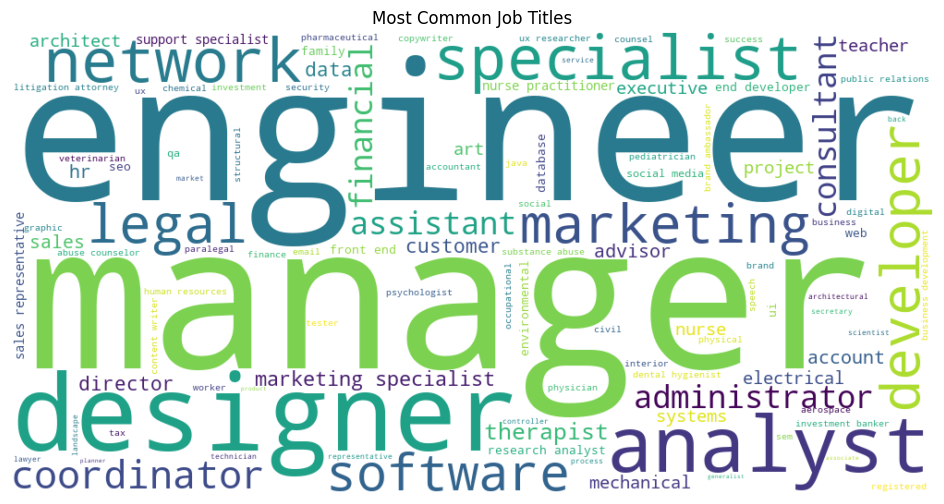

In [65]:
from wordcloud import WordCloud

text = " ".join(filtered_jd_df['Job Title'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Job Titles")
plt.savefig("Most Common Job Title", dpi=300, bbox_inches='tight')
plt.show()

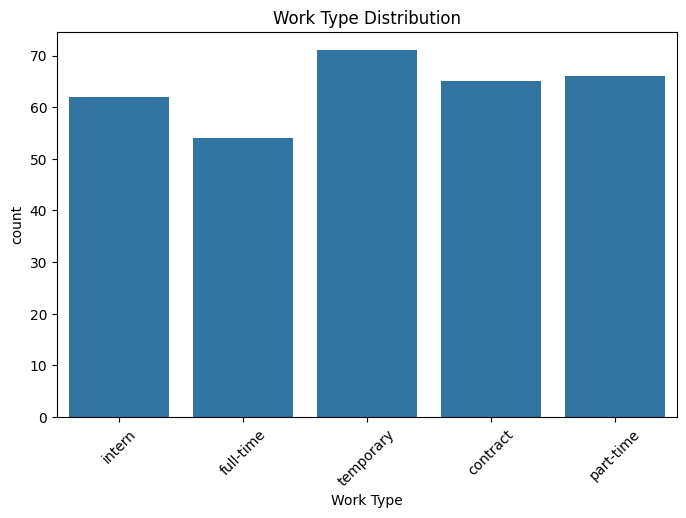

In [66]:
plt.figure(figsize=(8, 5))
sns.countplot(data=filtered_jd_df, x='Work Type')
plt.xticks(rotation=45)
plt.title("Work Type Distribution")
plt.savefig("Work Type Distribution", dpi=300, bbox_inches='tight')
plt.show()

In [45]:
#pip install squarify

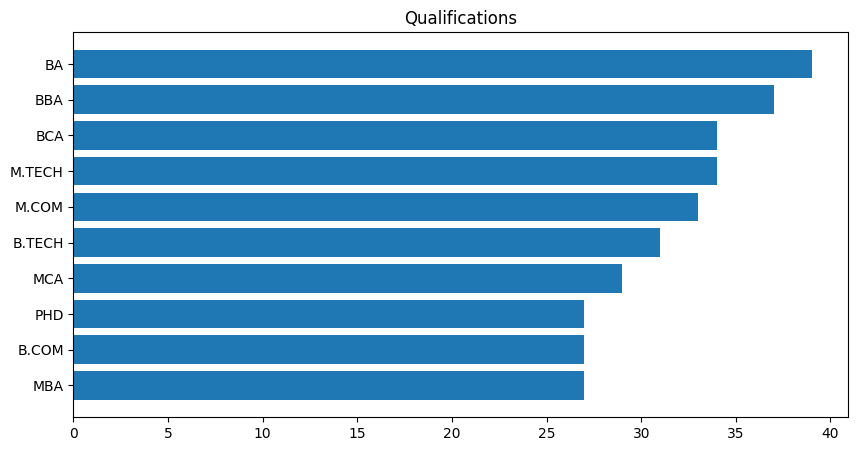

In [57]:
qualifications = filtered_jd_df['Qualifications'].value_counts()
qualifications.index=[q.upper() for q in qualifications.index]
plt.figure(figsize=(10,5))
plt.barh(qualifications.index, qualifications.values)
plt.title("Qualifications")
plt.gca().invert_yaxis()
plt.savefig("Qualifications.png", dpi=300, bbox_inches='tight')
plt.show()

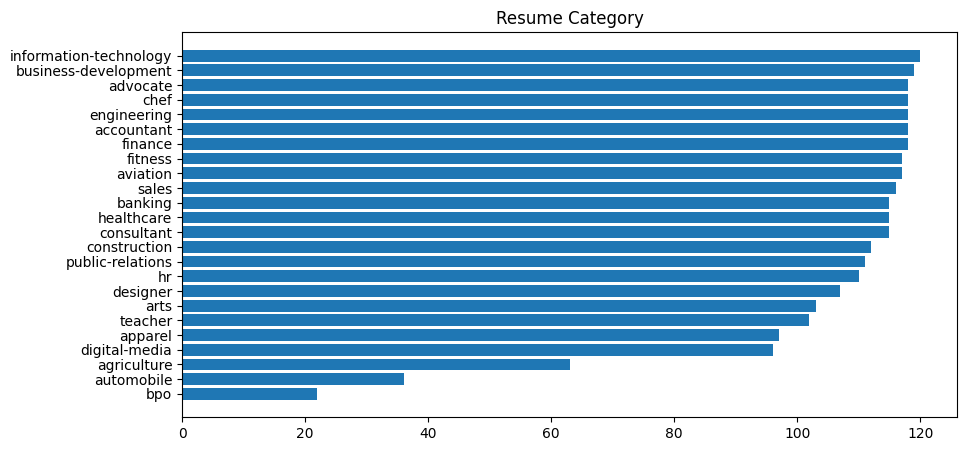

In [61]:
categ=resume_df['Category'].value_counts()
plt.figure(figsize=(10,5))
plt.barh(categ.index, categ.values)
plt.title("Resume Category")
plt.gca().invert_yaxis()
plt.savefig("Resume Category.png", dpi=300, bbox_inches='tight')
plt.show()

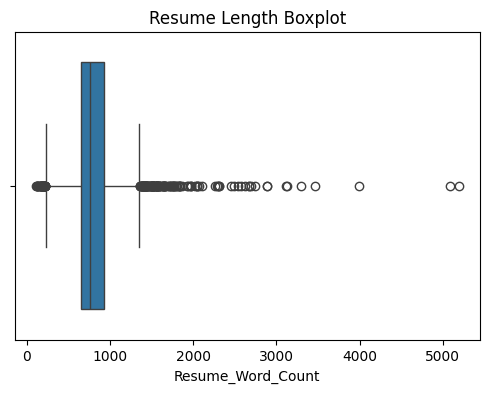

In [64]:
plt.figure(figsize=(6,4))
sns.boxplot(x=resume_df['Resume_Word_Count'])
plt.title("Resume Length Boxplot")
plt.savefig("Resume Length Boxplot.png", dpi=300, bbox_inches='tight')
plt.show()

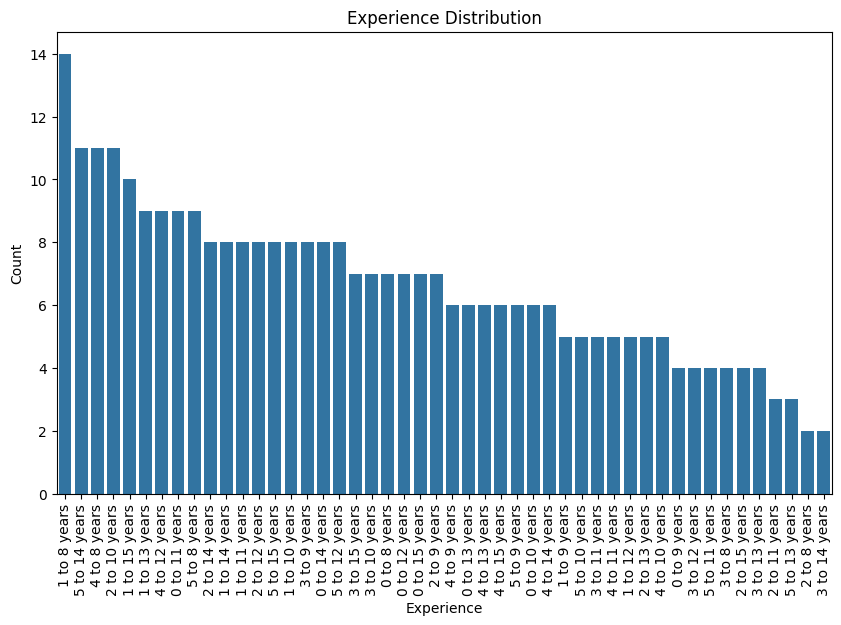

In [67]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=filtered_jd_df,
    x="Experience",
    order=filtered_jd_df["Experience"].value_counts().index
)

plt.xticks(rotation=90)
plt.xlabel("Experience")
plt.ylabel("Count")
plt.title("Experience Distribution")

plt.savefig("Experience Distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

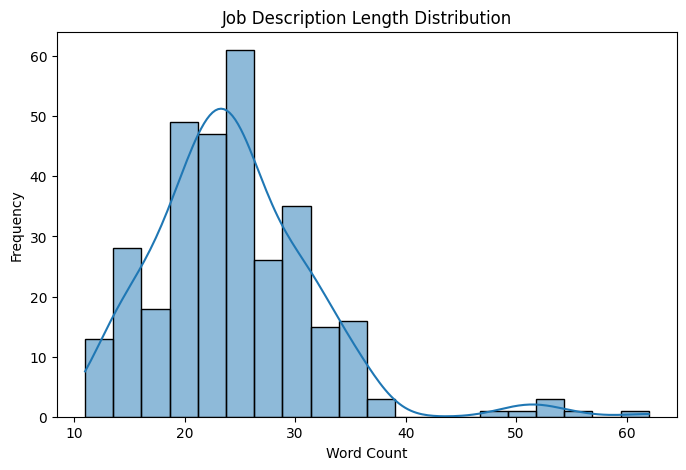

In [68]:
plt.figure(figsize=(8,5))

sns.histplot(
    filtered_jd_df["JD_Word_Count"],
    bins=20,
    kde=True
)

plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.title("Job Description Length Distribution")

plt.savefig("Job Description Length Distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

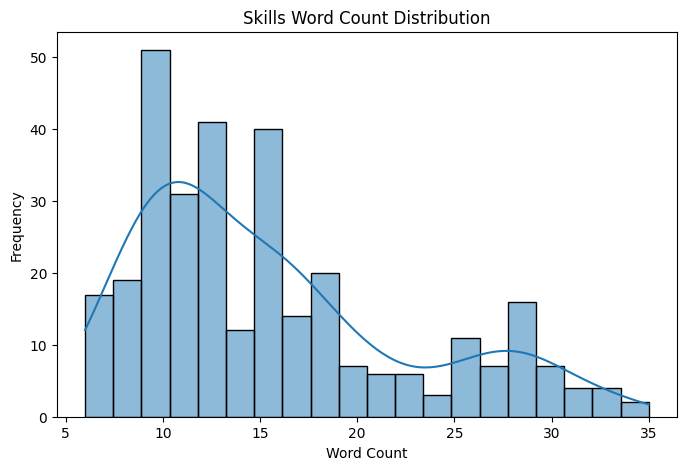

In [69]:
plt.figure(figsize=(8,5))

sns.histplot(
    filtered_jd_df["skills_Word_Count"],
    bins=20,
    kde=True
)

plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.title("Skills Word Count Distribution")

plt.savefig("Skills Word Count Distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

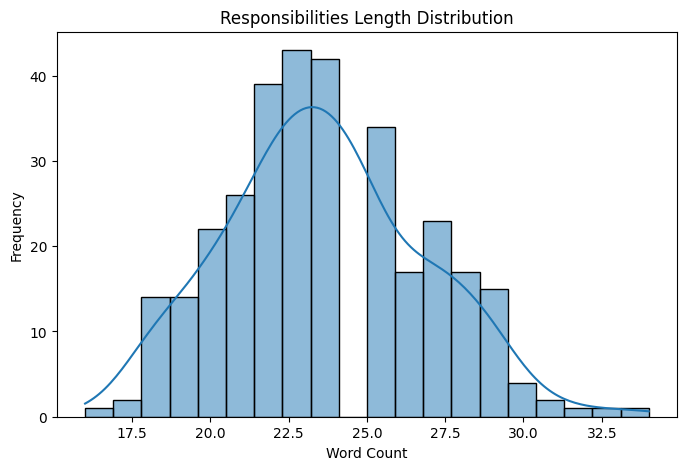

In [70]:
plt.figure(figsize=(8,5))

sns.histplot(
    filtered_jd_df["Responsibilities_Word_Count"],
    bins=20,
    kde=True
)

plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.title("Responsibilities Length Distribution")

plt.savefig("Responsibilities Length Distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [45]:
filtered_jd_df.to_csv("filtered_jd_df.csv",index=False)
resume_df.to_csv("resume_df.csv",index=False)